# UniGlyph — Python quickstart

`uniglyph` is a Cython extension over the UniGlyph C ABI, shipped as a
self-contained wheel: the native library travels inside the package, so
installing it needs neither Nim nor a compiler.

```
pip install lituus-uniglyph
```

## What the engine does, and does not

`capabilities()` is a bitmask of what the shaper implements. Reading it beats
guessing: this build maps codepoints to glyphs and applies pair kerning, and
does not do OpenType substitution, bidirectional reordering or mark
attachment.

In [1]:
import uniglyph
from uniglyph import Capability

print("version =", uniglyph.version(), "| abi =", uniglyph.abi_version())
print("has     =", [flag.name for flag in Capability
                    if uniglyph.capabilities() & flag])
print("lacks   =", [flag.name for flag in Capability
                    if not uniglyph.capabilities() & flag])

version = 1.0.0 | abi = 1
has     = ['NOMINAL_MAPPING', 'PAIR_KERNING']
lacks   = ['OPENTYPE_SUBSTITUTION', 'OPENTYPE_POSITIONING', 'COMPLEX_BIDI', 'MARK_ATTACHMENT']


## A font to read

The wheel carries DejaVu Sans so this notebook renders wherever it is
installed. `importlib.resources` finds it without knowing where that is.

In [2]:
import importlib.resources

from uniglyph import Font

FONT = str(importlib.resources.files("uniglyph") / "data" / "DejaVuSans.ttf")
face = Font(FONT)

print("units_per_em =", face.units_per_em)
print("ascent       =", face.ascent)
print("descent      =", face.descent)
print("line_gap     =", face.line_gap)
print("num_glyphs   =", face.num_glyphs)

units_per_em = 2048
ascent       = 1901
descent      = -483
line_gap     = 0
num_glyphs   = 4089


## Metrics scale from font units

Those numbers are in font units, not pixels. A line at 16 px is
`(ascent - descent + line_gap) / units_per_em * 16`, which the library computes
for you.

In [3]:
expected = (face.ascent - face.descent + face.line_gap) / face.units_per_em * 16

print("line_height(16) =", face.line_height(16.0))
print("by hand         =", expected)

line_height(16) = 18.625
by hand         = 18.625


## Glyphs and kerning

`glyph_id` maps a codepoint to a glyph index, and a font that lacks the
codepoint says so rather than guessing. Kerning is returned in font units and
is negative where a pair tucks together — `AV` is the textbook case.

In [4]:
A, V = face.glyph_id(ord("A")), face.glyph_id(ord("V"))

print("has 'A'          =", face.has_glyph(ord("A")), "-> glyph", A)
print("has U+4E2D       =", face.has_glyph(0x4E2D))
print("advance of 'A'   =", face.advance(A))
print("kerning A then V =", face.kerning(A, V))
print("text_width       =", face.text_width("Hello", 16.0))

has 'A'          = True -> glyph 36
has U+4E2D       = False
advance of 'A'   = 1401
kerning A then V = -131
text_width       = 40.5546875


## Content identity

`identity` hashes the bytes of the face, so two paths holding the same file
answer the same thing and a re-encoded file does not.

In [5]:
print("identity_hex =", face.identity_hex[:32], "...")
print("same file, same identity =", Font(FONT).identity == face.identity)

identity_hex = f28bcda21ddd9213881baaaa3d4158f1 ...
same file, same identity = True


## Laying out a line

`Layout` shapes text once and answers questions about the result. Its
typographic box spans the full line height; the ink box is what the glyphs
actually cover, which is smaller on both axes.

In [6]:
from uniglyph import Layout

line = Layout(face, "Hello, UniGlyph", 16.0)

print("size        =", (line.width, line.height))
print("lines       =", line.line_count)
print("glyphs      =", len(line.glyphs()))
print("typographic =", line.bounds())
print("ink         =", line.bounds(ink=True))

size        = (123.6328125, 18.625)
lines       = 1
glyphs      = 15
typographic = (0.0, 0.0, 123.6328125, 18.625)
ink         = (1.5703125, 2.6953125, 122.2734375, 18.1796875)


## Wrapping

Give `max_width` and the layout breaks at word boundaries. Each line reports
its own advance, so none of them exceeds the width asked for.

In [7]:
wrapped = Layout(face, "the quick brown fox jumps over the lazy dog", 14.0,
                 max_width=120.0)

print("lines  =", wrapped.line_count, "| height =", wrapped.height)
for index, row in enumerate(wrapped.lines()):
    print(f"  line {index} advance = {row['advance']:.4f}")

lines  = 3 | height = 48.890625
  line 0 advance = 112.5537
  line 1 advance = 104.0498
  line 2 advance = 86.3174


## A codepoint the font does not have

Shaping does not fail on it: the glyph becomes 0, the `.notdef` box, while the
cluster keeps the codepoint that asked for it. That is what lets a caller
notice and pick a fallback face.

In [8]:
missing = Layout(face, "CJK: 中", 16.0)
last = missing.glyphs()[-1]

print("glyph     =", last["glyph"])
print("codepoint =", last["codepoint"], "(U+%04X)" % last["codepoint"])

glyph     = 0
codepoint = 20013 (U+4E2D)


## Rendering

`render_to` draws a shaped layout onto an RGBA8 image, and `encode_png` hands
back PNG bytes.

In [9]:
from uniglyph import Color, Image

image = Image(220, 40)
Layout(face, "Hello, UniGlyph", 24.0).render_to(
    image, Color.parse("#1a1a1a"), 6.0, 30.0)

png = image.encode_png()

print("image     =", (image.width, image.height), "| channels =", image.channels)
print("png magic =", png[:4])

image     = (220, 40) | channels = 4
png magic = b'\x89PNG'


The rendered surface, as PNG bytes the notebook hands to the browser:

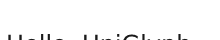

In [10]:
from IPython.display import Image as Show

Show(data=image.encode_png(), format="png")

## Colors are parsed or built, never constructed

`Color` has no public constructor: `Color.rgba` takes straight-alpha floats in
`[0, 1]`, and `Color.parse` reads a CSS Color 4 string.

In [11]:
try:
    Color(26, 26, 26)
except TypeError as exc:
    print("Color(...) ->", exc)

print("parse ok  =", Color.parse("#1a1a1a").__class__.__name__)
print("rgba ok   =", Color.rgba(0.1, 0.1, 0.1).__class__.__name__)

Color(...) -> Color values are created by Color.rgba() or Color.parse()
parse ok  = Color
rgba ok   = Color


## An atlas for repeated text

`Atlas` rasterises a set of codepoints once into a single sheet, which is what
a GPU renderer samples from. Asking for a codepoint twice does not pack it
twice.

In [12]:
from uniglyph import Atlas

atlas = Atlas(face, [ord(c) for c in "AVAW"], 24.0, width=128)
entry = atlas.entries()[0]

print("sheet   =", (atlas.width, atlas.height))
print("entries =", len(atlas.entries()), "for 4 codepoints, A asked twice")
print("first   = glyph %d at (%d, %d), %dx%d" % (
    entry["glyph"], entry["x"], entry["y"], entry["width"], entry["height"]))

sheet   = (128, 20)
entries = 3 for 4 codepoints, A asked twice
first   = glyph 36 at (1, 1), 17x18
